# Bulk RNA seq analysis of GBM models with and without EGFRvIII-overexpression

This notebook contains code to differential gene expression analysis for our EGFRvIII overexpression analysis. The input is a counts file generated after alignment. 

In [1]:
library(DESeq2)
library(dplyr)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: 'S4Vectors'


The following object is masked from 'package:utils':

    findMatches


The following objects are masked from 'package:base':

    expand.grid, I, unname


Loading required package: IRanges


Attaching package: 'IRanges'


The following object is masked from 'package:grDevic

In [2]:
# read in data 
table <- read.table("D:/BT/ecEGFR/manuscript/figures/EGFR_lenti_OE/GBM_FeatureCounts_AllGenes.txt", header = T,stringsAsFactors = F,row.names = 1) 

In [3]:
head(table)

,GBM39_1Aligned.sortedByCoord.out.bam,GBM39_2Aligned.sortedByCoord.out.bam,GBM39_3Aligned.sortedByCoord.out.bam,GBM39V3_1Aligned.sortedByCoord.out.bam,GBM39V3_2Aligned.sortedByCoord.out.bam,GBM39V3_3Aligned.sortedByCoord.out.bam,GSC11_1Aligned.sortedByCoord.out.bam,GSC11_2Aligned.sortedByCoord.out.bam,GSC11_3Aligned.sortedByCoord.out.bam,GSC11V3_1Aligned.sortedByCoord.out.bam,⋯,PN_3Aligned.sortedByCoord.out.bam,PNV3_1Aligned.sortedByCoord.out.bam,PNV3_2Aligned.sortedByCoord.out.bam,PNV3_3Aligned.sortedByCoord.out.bam,U87_1Aligned.sortedByCoord.out.bam,U87_2Aligned.sortedByCoord.out.bam,U87_3Aligned.sortedByCoord.out.bam,U87V3_1Aligned.sortedByCoord.out.bam,U87V3_2Aligned.sortedByCoord.out.bam,U87V3_3Aligned.sortedByCoord.out.bam
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
TSPAN6,1111,1121,1382,1618,836,1321,1143,1797,1317,1506,⋯,2952,1168,1173,1696,1278,947,1048,1152,1271,988
TNMD,1,2,2,0,0,1,0,0,1,1,⋯,10,4,2,10,0,0,0,1,3,0
DPM1,1151,1263,1482,1698,912,1407,850,1294,926,956,⋯,3216,1663,1600,2464,2247,1683,2198,1851,2002,1776
SCYL3,190,181,217,253,127,224,236,332,201,217,⋯,444,170,175,239,148,110,98,106,108,116
FIRRM,659,759,742,831,489,764,709,1104,764,653,⋯,1586,826,865,1247,366,265,470,223,283,307
FGR,0,0,0,1,1,0,0,0,2,0,⋯,13,16,12,15,4,0,2,1,1,2


In [4]:
# strip suffix
colnames(table) <- sub("Aligned.*$", "", colnames(table))

In [5]:
# remove genes with less than 10 counts total across all samples
gene.counts <- table

In [6]:
# Calculate the sum of counts for each gene (row)
row_sums <- apply(gene.counts, 1, sum)

In [7]:
# Create a logical vector where TRUE indicates a sum > 10
rows_keep <- row_sums > 10

In [8]:
# Subset the dataframe to keep only the desired rows
background_genes <- gene.counts[rows_keep, ]

In [9]:
head(background_genes)

,GBM39_1,GBM39_2,GBM39_3,GBM39V3_1,GBM39V3_2,GBM39V3_3,GSC11_1,GSC11_2,GSC11_3,GSC11V3_1,⋯,PN_3,PNV3_1,PNV3_2,PNV3_3,U87_1,U87_2,U87_3,U87V3_1,U87V3_2,U87V3_3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
TSPAN6,1111,1121,1382,1618,836,1321,1143,1797,1317,1506,⋯,2952,1168,1173,1696,1278,947,1048,1152,1271,988
TNMD,1,2,2,0,0,1,0,0,1,1,⋯,10,4,2,10,0,0,0,1,3,0
DPM1,1151,1263,1482,1698,912,1407,850,1294,926,956,⋯,3216,1663,1600,2464,2247,1683,2198,1851,2002,1776
SCYL3,190,181,217,253,127,224,236,332,201,217,⋯,444,170,175,239,148,110,98,106,108,116
FIRRM,659,759,742,831,489,764,709,1104,764,653,⋯,1586,826,865,1247,366,265,470,223,283,307
FGR,0,0,0,1,1,0,0,0,2,0,⋯,13,16,12,15,4,0,2,1,1,2


### DESEQ2 Differential gene expression analysis

In [10]:
# Make labels for comparison

labels <- factor(c("ctrl","ctrl","ctrl",
                   "EGFRvIII_OE", "EGFRvIII_OE", "EGFRvIII_OE",
                   "ctrl","ctrl","ctrl",
                   "EGFRvIII_OE", "EGFRvIII_OE", "EGFRvIII_OE",
                   "ctrl","ctrl","ctrl",
                   "EGFRvIII_OE", "EGFRvIII_OE", "EGFRvIII_OE",
                   "ctrl","ctrl","ctrl",
                   "EGFRvIII_OE", "EGFRvIII_OE", "EGFRvIII_OE",
                   "ctrl","ctrl","ctrl",
                   "EGFRvIII_OE", "EGFRvIII_OE", "EGFRvIII_OE")) 

# can do this a bunch of ways but we are going to start with BRAF vs. no BRAF (can do BRAF with and without EGFR, etc.)
#for the program to know that they are the same condition, they need to have the same title/name, etc.

In [11]:
labels.df <- DataFrame(condition = labels, row.names = colnames(gene.counts)) 

In [12]:
rownames(labels.df)

[1] "GBM39_1"   "GBM39_2"   "GBM39_3"   "GBM39V3_1" "GBM39V3_2" "GBM39V3_3"
 [7] "GSC11_1"   "GSC11_2"   "GSC11_3"   "GSC11V3_1" "GSC11V3_2" "GSC11V3_3"
[13] "GSC23_1"   "GSC23_2"   "GSC23_3"   "GSC23V3_1" "GSC23V3_2" "GSC23V3_3"
[19] "PN_1"      "PN_2"      "PN_3"      "PNV3_1"    "PNV3_2"    "PNV3_3"   
[25] "U87_1"     "U87_2"     "U87_3"     "U87V3_1"   "U87V3_2"   "U87V3_3"

In [13]:
labels.df

DataFrame with 30 rows and 1 column
            condition
             <factor>
GBM39_1   ctrl       
GBM39_2   ctrl       
GBM39_3   ctrl       
GBM39V3_1 EGFRvIII_OE
GBM39V3_2 EGFRvIII_OE
...               ...
U87_2     ctrl       
U87_3     ctrl       
U87V3_1   EGFRvIII_OE
U87V3_2   EGFRvIII_OE
U87V3_3   EGFRvIII_OE

In [14]:
labels.df$cell_line <- sub("(_[0-9]+)$", "", rownames(labels.df))
labels.df$cell_line <- sub("V3$", "", labels.df$cell_line)

In [15]:
labels.df$replicate <- sub("^.*_([0-9]+)$", "\\1", rownames(labels.df))

In [16]:
# convert to factor for DESeq2
labels.df$cell_line <- factor(labels.df$cell_line)
labels.df$condition <- factor(labels.df$condition)
labels.df$replicate <- factor(labels.df$replicate)

In [17]:
labels.df

DataFrame with 30 rows and 3 columns
            condition cell_line replicate
             <factor>  <factor>  <factor>
GBM39_1   ctrl            GBM39         1
GBM39_2   ctrl            GBM39         2
GBM39_3   ctrl            GBM39         3
GBM39V3_1 EGFRvIII_OE     GBM39         1
GBM39V3_2 EGFRvIII_OE     GBM39         2
...               ...       ...       ...
U87_2     ctrl              U87         2
U87_3     ctrl              U87         3
U87V3_1   EGFRvIII_OE       U87         1
U87V3_2   EGFRvIII_OE       U87         2
U87V3_3   EGFRvIII_OE       U87         3

In [18]:
# create dds

dds <- DESeqDataSetFromMatrix(
    countData = gene.counts,
    colData = labels.df,
    design = ~ cell_line + condition
)

In [19]:
dds <- DESeq(dds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [20]:
res <- results(dds, contrast = c("condition", "EGFRvIII_OE", "ctrl")) #pulls results 

#compares vIII-OE vs. parental

In [21]:
res.df <- as.data.frame(res) #writes it into a dataframe

In [22]:
head(res.df) #viewing the table

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TSPAN6,1638.370575,0.01652028,0.04723943,0.3497138,0.72655349,0.8767305
TNMD,1.768159,0.74821055,0.66382418,1.1271216,0.25969109,NA
DPM1,2122.372554,0.04242418,0.03315108,1.2797225,0.20064276,0.4461912
SCYL3,297.373703,-0.10906954,0.04815562,-2.2649391,0.02351641,0.1106661
FIRRM,966.981545,-0.08005255,0.06488152,-1.2338265,0.21726755,0.4680050
FGR,3.298783,0.50392014,0.46493111,1.0838598,0.27842697,NA


In [23]:
#write.table(res.df,file="D:/BT/ecEGFR/manuscript/figures/EGFR_lenti_OE/20260205_GBM_EGFR_OE_DESeq2_output.txt", #data file
#            sep="\t", #tab delineated file 
#            quote=FALSE, # literally quotes to the name if it isn't a number..can help with keeping table in check 
#            row.names=TRUE) #writing it out to the file

In [24]:
significantGenes <- subset (res.df, padj <= 0.05)
dim(significantGenes)

[1] 3302    6

In [25]:
head(significantGenes)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NFYA,1733.06664,-0.1055779,0.03672787,-2.874599,4.045414e-03,3.115674e-02
LAP3,3266.42050,0.1586101,0.03691667,4.296436,1.735661e-05,4.234613e-04
HS3ST1,281.80922,0.8939408,0.15172573,5.891821,3.819631e-09,3.635672e-07
MAD1L1,51.94566,0.5364967,0.14223343,3.771945,1.619798e-04,2.608637e-03
CYP26B1,185.62830,0.7741265,0.17391441,4.451192,8.539489e-06,2.389613e-04
AK2,8242.21576,0.1376075,0.02910582,4.727834,2.269271e-06,8.150176e-05


In [26]:
sig_genes_pos <- subset(significantGenes, log2FoldChange >= 1)
head(sig_genes_pos)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CAMK1G,10.95219,1.286458,0.3727249,3.451495,5.574904e-04,6.818676e-03
CNTN1,334.75466,1.427953,0.1715139,8.325586,8.391289e-17,4.452838e-14
CD74,2629.44624,3.176139,0.5845519,5.433460,5.527169e-08,3.533726e-06
PTPRN,1800.34285,1.014576,0.2270920,4.467687,7.906982e-06,2.246768e-04
CHI3L2,104.39224,1.224858,0.2023738,6.052453,1.426562e-09,1.552831e-07
HES2,23.83974,1.252099,0.1801120,6.951781,3.607018e-12,7.580452e-10


In [27]:
sig_genes_neg <- subset(significantGenes, log2FoldChange <= -1)
head(sig_genes_neg)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PTGER3,43.452008,-1.095402,0.2302313,-4.757833,1.956824e-06,7.148975e-05
GLP2R,31.818185,-1.133796,0.3370828,-3.363554,7.694580e-04,8.833438e-03
ABCB1,31.340328,-1.006284,0.3316612,-3.034072,2.412772e-03,2.112899e-02
POU2AF1,6.126596,-1.179293,0.4350104,-2.710953,6.709022e-03,4.500812e-02
UNC93A,12.055891,-1.115388,0.3564262,-3.129365,1.751846e-03,1.657071e-02
SLC5A7,52.222461,-1.257001,0.1900285,-6.614804,3.720451e-11,5.937617e-09


In [28]:
dim(significantGenes)
dim(sig_genes_pos)
dim(sig_genes_neg)

[1] 3302    6

[1] 207   6

[1] 51  6

In [29]:
# the below tables will be used for ORA/Enrichr analysis (e.g., what are signifcantly enriched genes with at least a positive 2-fold change)

In [30]:
#write.table(significantGenes,
#            file="D:/BT/ecEGFR/manuscript/figures/EGFR_lenti_OE/20260205_GBM_EGFR_OE_DESeq2_significant_genes.txt",
#            sep="\t", #tab delineated file 
#            quote=FALSE, # literally quotes to the name if it isn't a number..can help with keeping table in check 
#            row.names=TRUE) #writing it out to the file

In [31]:
#write.table(sig_genes_pos,
#            file="D:/BT/ecEGFR/manuscript/figures/EGFR_lenti_OE/20260205_GBM_EGFR_OE_DESeq2_significant_genes_positive.txt",
#            sep="\t", #tab delineated file 
#            quote=FALSE, # literally quotes to the name if it isn't a number..can help with keeping table in check 
#            row.names=TRUE) #writing it out to the file

In [32]:
#write.table(sig_genes_neg,
#            file="D:/BT/ecEGFR/manuscript/figures/EGFR_lenti_OE/20260205_GBM_EGFR_OE_DESeq2_significant_genes_negative.txt",
#            sep="\t", #tab delineated file 
#            quote=FALSE, # literally quotes to the name if it isn't a number..can help with keeping table in check 
#            row.names=TRUE) #writing it out to the file

In [33]:
# plotting the rlog version of the data
#plot(norm_matrix[,1],norm_matrix[,2],pch=".")

In [34]:
library(genefilter)
library(pheatmap)
library(EnhancedVolcano)


Attaching package: 'genefilter'


The following objects are masked from 'package:MatrixGenerics':

    rowSds, rowVars


The following objects are masked from 'package:matrixStats':

    rowSds, rowVars


Loading required package: ggplot2

Loading required package: ggrepel



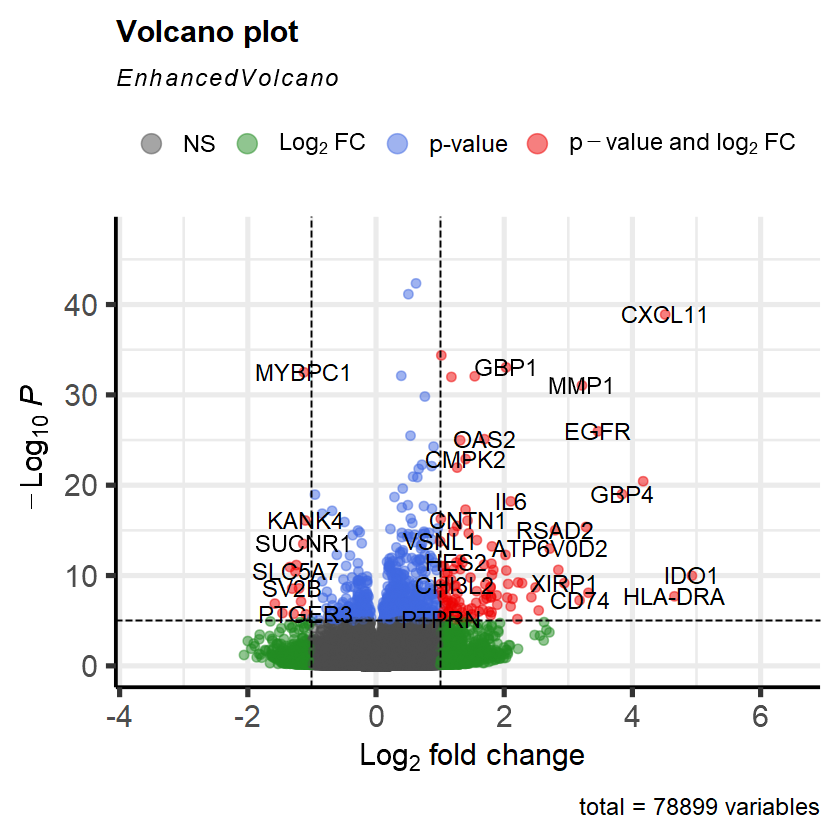

In [35]:
EnhancedVolcano(res,
    lab = rownames(res),
    x = 'log2FoldChange',
    y = 'pvalue')

In [36]:
#jpeg("D:/BT/ecEGFR/manuscript/figures/EGFR_lenti_OE/plots/volcano_GBM_EGFR_OE_DESeq2.jpg")
#EnhancedVolcano(res.df,
#    lab = rownames(res),
#    x = 'log2FoldChange',
#    y = 'pvalue',
#    title = 'GBM39_EGFRvIII_OE vs ctrl',
#   pCutoff = .05,
#    FCcutoff = 1,
#    pointSize = 3.0,
#    labSize = 6.0)
#dev.off()

In [37]:
normalized_counts <- counts(dds, normalized = TRUE)
head(normalized_counts)

,GBM39_1,GBM39_2,GBM39_3,GBM39V3_1,GBM39V3_2,GBM39V3_3,GSC11_1,GSC11_2,GSC11_3,GSC11V3_1,⋯,PN_3,PNV3_1,PNV3_2,PNV3_3,U87_1,U87_2,U87_3,U87V3_1,U87V3_2,U87V3_3
TSPAN6,1464.223522,1421.145565,1621.99109,1455.6007102,1413.354654,1383.86592,1611.3303,1682.0848,1741.752587,2144.869063,⋯,1838.738639,1417.77958,1476.246727,1577.611411,1350.034828,1332.8084,1252.451060,1574.627948,1574.184026,1356.392413
TNMD,1.317933,2.535496,2.34731,0.0000000,0.000000,1.04759,0.0000,0.0000,1.322515,1.424216,⋯,6.228789,4.85541,2.517045,9.301954,0.000000,0.0000,0.000000,1.366865,3.715619,0.000000
DPM1,1516.940841,1601.165789,1739.35658,1527.5710791,1541.841441,1473.95863,1198.2771,1211.2508,1224.649124,1361.550348,⋯,2003.178680,2018.63651,2013.635774,2292.001483,2373.652785,2368.6552,2626.800983,2530.066260,2479.556586,2438.211463
SCYL3,250.407263,229.462397,254.68312,227.6062915,214.708183,234.66008,332.6981,310.7691,265.825566,309.054838,⋯,276.558251,206.35491,220.241413,222.316702,156.342061,154.8141,117.118515,144.887641,133.762293,159.252551
FIRRM,868.517823,962.220771,870.85195,747.5922066,826.711036,800.35849,999.5041,1033.4010,1010.401653,930.012947,⋯,987.886003,1002.64207,1088.621840,1159.953673,386.629693,372.9612,561.690838,304.810792,350.506750,421.470112
FGR,0.000000,0.000000,0.00000,0.8996296,1.690616,0.00000,0.0000,0.0000,2.645031,0.000000,⋯,8.097426,19.42164,15.102268,13.952931,4.225461,0.0000,2.390174,1.366865,1.238540,2.745734


In [38]:
#write.table(normalized_counts,file="D:/BT/ecEGFR/manuscript/figures/EGFR_lenti_OE/plots/20260205_GBM39_EGFRvIII_OE_normalized_counts", #data file
#            sep="\t", #tab delineated file 
#            quote=FALSE, # literally quotes to the name if it isn't a number..can help with keeping table in check 
#            row.names=TRUE) #writing it out to the file

In [39]:
# basically want to investigate their "GBM cell identity" and if EGFRvIII-OE cells are enriched in MES-like genes...

In [40]:
##### MASTER GBM GENE SET
genesets <- read.csv("D:/BT/ecEGFR/master_GBM_identity_gene_set.csv",
                     stringsAsFactors = FALSE)

In [41]:
head(genesets)

,Author,Geneset_name,Author_Geneset,Gene_id,Dataset,Source,Paper_source
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Verhaak,Mesenchymal,Verhaak_Mesenchymal,ACP3,https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/VERHAAK_GLIOBLASTOMA_MESENCHYMAL,VERHAAK_GLIOBLASTOMA_MESENCHYMAL,https://www.sciencedirect.com/science/article/pii/S1535610809004322?via%3Dihub
2,Verhaak,Mesenchymal,Verhaak_Mesenchymal,ACSL1,https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/VERHAAK_GLIOBLASTOMA_MESENCHYMAL,VERHAAK_GLIOBLASTOMA_MESENCHYMAL,https://www.sciencedirect.com/science/article/pii/S1535610809004322?via%3Dihub
3,Verhaak,Mesenchymal,Verhaak_Mesenchymal,ADAM12,https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/VERHAAK_GLIOBLASTOMA_MESENCHYMAL,VERHAAK_GLIOBLASTOMA_MESENCHYMAL,https://www.sciencedirect.com/science/article/pii/S1535610809004322?via%3Dihub
4,Verhaak,Mesenchymal,Verhaak_Mesenchymal,ALDH3B1,https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/VERHAAK_GLIOBLASTOMA_MESENCHYMAL,VERHAAK_GLIOBLASTOMA_MESENCHYMAL,https://www.sciencedirect.com/science/article/pii/S1535610809004322?via%3Dihub
5,Verhaak,Mesenchymal,Verhaak_Mesenchymal,ALOX5,https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/VERHAAK_GLIOBLASTOMA_MESENCHYMAL,VERHAAK_GLIOBLASTOMA_MESENCHYMAL,https://www.sciencedirect.com/science/article/pii/S1535610809004322?via%3Dihub
6,Verhaak,Mesenchymal,Verhaak_Mesenchymal,AMPD3,https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/VERHAAK_GLIOBLASTOMA_MESENCHYMAL,VERHAAK_GLIOBLASTOMA_MESENCHYMAL,https://www.sciencedirect.com/science/article/pii/S1535610809004322?via%3Dihub


In [42]:
# optional cleanup
genesets$Gene_id <- toupper(trimws(genesets$Gene_id))

# 2) build pathways list: names = Author_Geneset, values = vector of genes
pathways <- genesets %>%
  distinct(Author_Geneset, Gene_id) %>%
  group_by(Author_Geneset) %>%
  summarize(genes = list(Gene_id), .groups = "drop") %>%
  { setNames(.$genes, .$Author_Geneset) }

# quick check
length(pathways)
head(names(pathways))

[1] 46

[1] "Greenwald_AC"                                   
[2] "Greenwald_Chromatin_regulation"                 
[3] "Greenwald_Inflammatory_macrophage_non_malignant"
[4] "Greenwald_MES_Hypoxia"                          
[5] "Greenwald_Macrophage_non_malignant"             
[6] "Greenwald_Mesenchymal"

In [43]:
### WANT to do GSVA
BiocManager::install(c("GSVA", "limma"))
library(GSVA)
library(limma)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.18 (BiocManager 1.30.27), R 4.3.3 (2024-02-29 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'GSVA' 'limma'"
Installation paths not writeable, unable to update packages
  path: C:/ProgramData/miniconda3/envs/r-seurat/Lib/R/library
  packages:
    abind, base64enc, BH, blob, boot, broom, bslib, Cairo, caret, clock,
    cluster, colorspace, cpp11, data.table, DBI, dbplyr, digest, dplyr, dqrng,
    dtplyr, e1071, fansi, fitdistrplus, forcats, foreign, fs, future,
    future.apply, gargle, ggplot2, ggrepel, globals, googledrive,
    googlesheets4, gower, gplots, here, highr, hms, htmltools, httpuv, httr,
    igraph, irlba, isoband, knitr, later, lattice, lava, leidenbase, lifecycle,
    li

In [44]:
vsd <- vst(dds, blind=FALSE)
expr <- assay(vsd)   # genes x samples

In [45]:
gs <- genesets

In [46]:
gs$Gene_id <- toupper(trimws(gs$Gene_id))

pathways <- split(gs$Gene_id, gs$Author_Geneset)
pathways <- lapply(pathways, unique)

In [47]:
pathways <- pathways[lengths(pathways) >= 10]

In [48]:
genes_in_data <- rownames(expr)
pathways <- lapply(pathways, intersect, y=genes_in_data)
pathways <- pathways[lengths(pathways) >= 10]

In [49]:
dim(expr)

[1] 78899    30

In [50]:
gsva_mat <- gsva(expr, pathways, method="ssgsea", ssgsea.norm=TRUE)
# result: pathways x samples

Warning message:
"Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva')."
Warning message in .filterFeatures(expr, method):
"22030 genes with constant expression values throughout the samples."


Estimating ssGSEA scores for 46 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


In [51]:
### Version with all MES together 

In [52]:
library(pheatmap)

keep_sets <- c(
  "Neftel_MES", "Nomura_Mesenchymal", "Greenwald_Mesenchymal", "Verhaak_Mesenchymal"
)

missing <- setdiff(keep_sets, rownames(gsva_mat))
missing
# if this prints anything, those names don't match your rownames exactly
# run: grep("Neftel", rownames(gsva_mat), value=TRUE) and grep("Verhaak", ...)

gsva_keep <- gsva_mat[keep_sets, , drop=FALSE]

character(0)

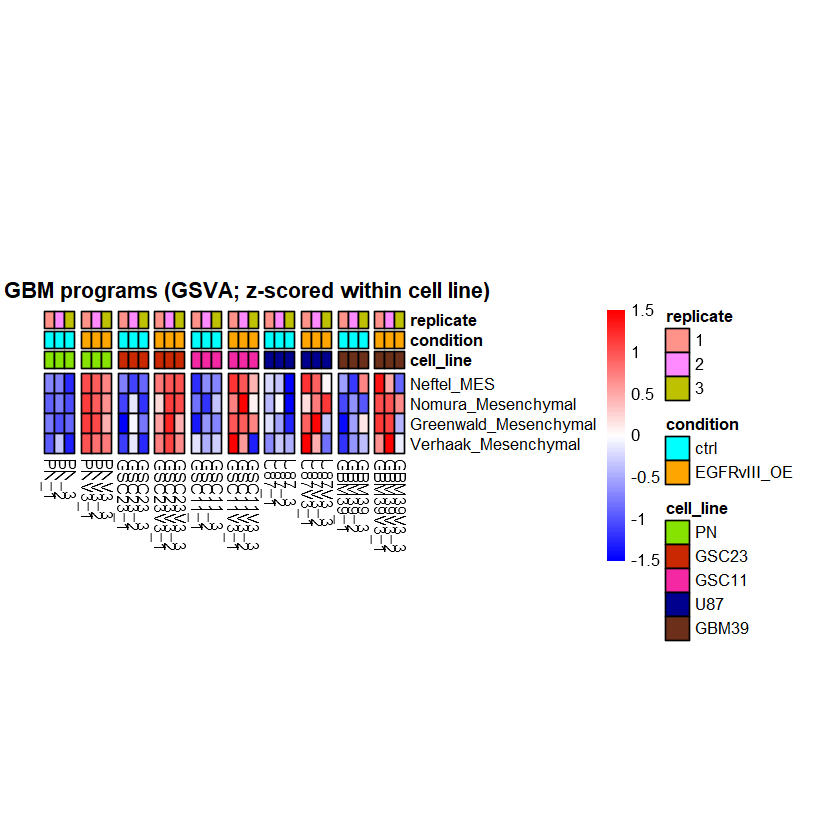

In [53]:
library(pheatmap)

# -------------------------------
# Sample annotation + ordering
# -------------------------------
anno <- as.data.frame(colData(dds)[, c("cell_line", "condition", "replicate")])

# set desired factor levels
anno$condition <- factor(anno$condition, levels = c("ctrl", "EGFRvIII_OE"))
cell_line_order <- c("PN", "GSC23", "GSC11", "U87", "GBM39")
anno$cell_line <- factor(anno$cell_line, levels = cell_line_order)

# if replicate column is missing or messy, parse from sample names instead
# anno$replicate <- suppressWarnings(as.integer(sub(".*_(\\d+)$", "\\1", rownames(anno))))

# order samples by cell line, then condition, then replicate
ord <- order(anno$cell_line, anno$condition, anno$replicate)
anno_ord <- anno[ord, , drop = FALSE]

# final annotation dataframe for plotting
ann_plot <- anno_ord[, c("cell_line", "condition", "replicate"), drop = FALSE]

# reorder GSVA matrix columns to match annotation
m_ord <- gsva_keep[, rownames(anno_ord), drop = FALSE]

# -------------------------------
# Z-score rows within each cell line block
# -------------------------------
m_z <- m_ord
for (cl in levels(anno_ord$cell_line)) {
  idx <- which(anno_ord$cell_line == cl)
  if (length(idx) < 2) next

  m_block <- m_ord[, idx, drop = FALSE]   # rows = gene sets, cols = samples for one cell line
  mz_block <- t(scale(t(m_block)))        # z-score each row across samples in this block
  mz_block[!is.finite(mz_block)] <- 0
  m_z[, idx] <- mz_block
}
m_z[!is.finite(m_z)] <- 0

# -------------------------------
# Column gaps
# -------------------------------

# gaps between cell lines
cell_counts <- table(anno_ord$cell_line)
cell_counts <- cell_counts[cell_counts > 0]
gaps_lines <- cumsum(as.integer(cell_counts))
gaps_lines <- gaps_lines[-length(gaps_lines)]

# gaps between ctrl and OE within each cell line
ctrl_counts <- tapply(anno_ord$condition == "ctrl", anno_ord$cell_line, sum)
ctrl_counts <- ctrl_counts[names(cell_counts)]  # align to present cell lines only

starts <- c(1, head(cumsum(as.integer(cell_counts)) + 1, -1))  # start column of each cell line block
gaps_ctrl_oe <- starts + as.integer(ctrl_counts) - 1           # last ctrl column in each block
gaps_ctrl_oe <- gaps_ctrl_oe[gaps_ctrl_oe < ncol(m_z)]         # keep valid positions

# combine all gaps
gaps_all <- sort(unique(c(gaps_lines, gaps_ctrl_oe)))

# -------------------------------
# Heatmap settings
# -------------------------------
q <- 0.99
cap <- as.numeric(quantile(abs(m_z), probs = q, na.rm = TRUE))
cap <- 1.5   # override if you want a fixed symmetric cap

cols <- colorRampPalette(c("blue", "white", "red"))(100)

cell_line_cols <- c(
  PN    = "#86e300",
  GSC23 = "#ca2800",
  GSC11 = "#f328a2",
  U87   = "#00008e",
  GBM39 = "#6B2F1A"
)

# -------------------------------
# Plot
# -------------------------------
pheatmap(
  m_z,
  color = cols,
  breaks = seq(-cap, cap, length.out = 101),
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  gaps_col = gaps_all,
  border_color = "black",
  annotation_col = ann_plot,
  annotation_colors = list(
    condition = c(ctrl = "cyan", EGFRvIII_OE = "orange"),
    cell_line = cell_line_cols
  ),
  cellwidth = 6,
  cellheight = 12,
  main = "Key GBM programs (GSVA; z-scored within cell line)"
)